**Table of contents**<a id='toc0_'></a>    
- 1. [Problem 1: Production economy and CO2 taxation](#toc1_)    
- 2. [Problem 2: Career choice model](#toc2_)    
- 3. [Problem 3: Barycentric interpolation](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
# Write your code here
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

%load_ext autoreload
%autoreload 2
from CareerChoice import CareerClass

## 2. <a id='toc2_'></a>[Problem 2: Career choice model](#toc0_)

Consider a graduate $i$ making a choice between entering $J$ different career tracks. <br>
Entering career $j$ yields utility $u^k_{ij}$. This value is unknown to the graduate ex ante, but will ex post be: <br>
$$
    u_{i,j}^k = v_{j} + \epsilon_{i,j}^k
$$

They know that $\epsilon^k_{i,j}\sim \mathcal{N}(0,\sigma^2)$, but they do not observe $\epsilon^k_{i,j}$ before making their career choice. <br>

Consider the concrete case of $J=3$ with:
$$
\begin{align*}
    v_{1} &= 1 \\
    v_{2} &= 2 \\
    v_{3} &= 3
\end{align*}
$$

If the graduates know the values of $v_j$ and the distribution of $\epsilon_{i,j}^k$, they can calculate the expected utility of each career track using simulation: <br>
$$
    \mathbb{E}\left[ u^k_{i,j}\vert v_j \right] \approx v_j + \frac{1}{K}\sum_{k=1}^K \epsilon_{i,j}^k
$$

**Question 1:** Simulate and calculate expected utility and the average realised utility for $K=10000$ draws, for each career choice $j$.
__________________________________________________________________________________________
**Answer:**


The code for solving all subquestions of question 2 is found in CareerChoice.py, it also contains the relevant documentation for each line of code. 

In short, for question 2.1, we create arrays to store expected and average realized utilities. We loop over each career {1,2,3}, where each iteration does a draw of 10.000, $ \epsilon_{i,j}^k \sim \mathcal{N} (0,\sigma^2)$, values, then calculate the expected utility, as listed in the assignment text. We then calculate the average realized utility, using the same draws, since it is not clear from the text whether they should be different. We then print the results using another loop. Ofcourse these to utility types are identical due to simple logic, i.e. the average of the K-sum of a constant is the constant itself. 

In [2]:
# Initialize class
career = CareerClass()

# Parameters can be changed here if wanted
career.par.J = 3 # number of careers
career.par.N = 10 # number of graduates
career.par.K = 10000 # number of simulations
career.par.i = np.array([1,2,3,4,5,6,7,8,9,10])

career.par.F = np.arange(1,career.par.N+1,1) # number of friends in each career
career.par.sigma = 2 # standard deviation of the normal distribution

career.par.v = np.arange(1,career.par.J+1, 1) # utility of each career
career.par.c = 1 # cost of switching career

# set seed if wanted, for reproducability, each career does K different draws. 
seed = 2024

# run the method that answers the question
career.expec_and_avg_utility(seed=seed)

Career 1 - Expected Utility: 1.0154, Average Utility: 1.0154
Career 2 - Expected Utility: 2.0064, Average Utility: 2.0064
Career 3 - Expected Utility: 3.0030, Average Utility: 3.0030


Since the graduate knows the value of $v_j$, and we keep the random draws as the actual realizations of the noise term, there expected and average utility are obviously the same. It is not clear from the exam text if this is whats intended. We could easily modify the class method to use different draws for the realized noise terms, or unique independent draws for every one of the 10.000*3 draws, which would yield different results. 

Secondly, when $\# draws \to \infty$ the sample mean will converge to the distribution mean of 0, and since that is 0, the choice of career will be based on the career with the highest baseline utility absent of any noise, which in this case, is career 3. 
__________________________________________________________________________________________

Now consider a new scenario: Imagine that the graduate does not know $v_j$. The *only* prior information they have on the value of each job, comes from their $F_{i}$ friends that work in each career $j$. After talking with them, they know the average utility of their friends (which includes their friends' noise term), giving them the prior expecation: <br>
$$
\tilde{u}^k_{i,j}\left( F_{i}\right) = \frac{1}{F_{i}}\sum_{f=1}^{F_{i}} \left(v_{j} + \epsilon^k_{f,j}\right), \; \epsilon^k_{f,j}\sim \mathcal{N}(0,\sigma^2)
$$
For ease of notation consider that each graduate have $F_{i}=i$ friends in each career. <br>

For $K$ times do the following: <br>
1. For each person $i$ draw $J\cdot F_i$ values of $\epsilon_{f,j}^{k}$, and calculate the prior expected utility of each career track, $\tilde{u}^k_{i,j}\left( F_{i}\right)$. <br>
Also draw their own $J$ noise terms, $\epsilon_{i,j}^k$
1. Each person $i$ chooses the career track with the highest expected utility: $$j_i^{k*}= \arg\max_{j\in{1,2\dots,J}}\left\{ \tilde{u}^k_{i,j}\left( F_{i}\right)\right\} $$
1. Store the chosen careers: $j_i^{k*}$, the prior expectation of the value of their chosen career: $\tilde{u}^k_{i,j=j_i^{k*}}\left( F_{i}\right)$, and the realized value of their chosen career track: $u^k_{i,j=j_i^{k*}}=v_{j=j_i^{k*}}+\epsilon_{i,j=j_i^{k*}}^k$.

Chosen values will be: <br>
$i\in\left\{1,2\dots,N\right\}, N=10$ <br>
$F_i = i$<br>
So there are 10 graduates. The first has 1 friend in each career, the second has 2 friends, ... the tenth has 10 friends.

**Question 2:** Simulate and visualize: For each type of graduate, $i$, the share of graduates choosing each career, the average subjective expected utility of the graduates, and the average ex post realized utility given their choice. <br>
That is, calculate and visualize: <br>
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \mathbb{I}\left\{ j=j_i^{k*} \right\}  \;\forall j\in\left\{1,2,\dots,J\right\}
\end{align*}
$$
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \tilde{u}^k_{ij=j_i^{k*}}\left( F_{i}\right)
\end{align*}
$$
And 
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} u^k_{ij=j_i^{k*}} 
\end{align*}
$$
For each graduate $i$.

__________________________________________________________________________________________
**Answer:**

This method is deemed to long to explain intuitively. The documentation in the CareerChoice.py file is sufficient to understand the method. It could probaly be optimized, since it does a K*N (100.000) loop. We chose to do the graphs directly in the method, where we probaly should have created a new method for making the graphs, since they are very similar between this and the next question.

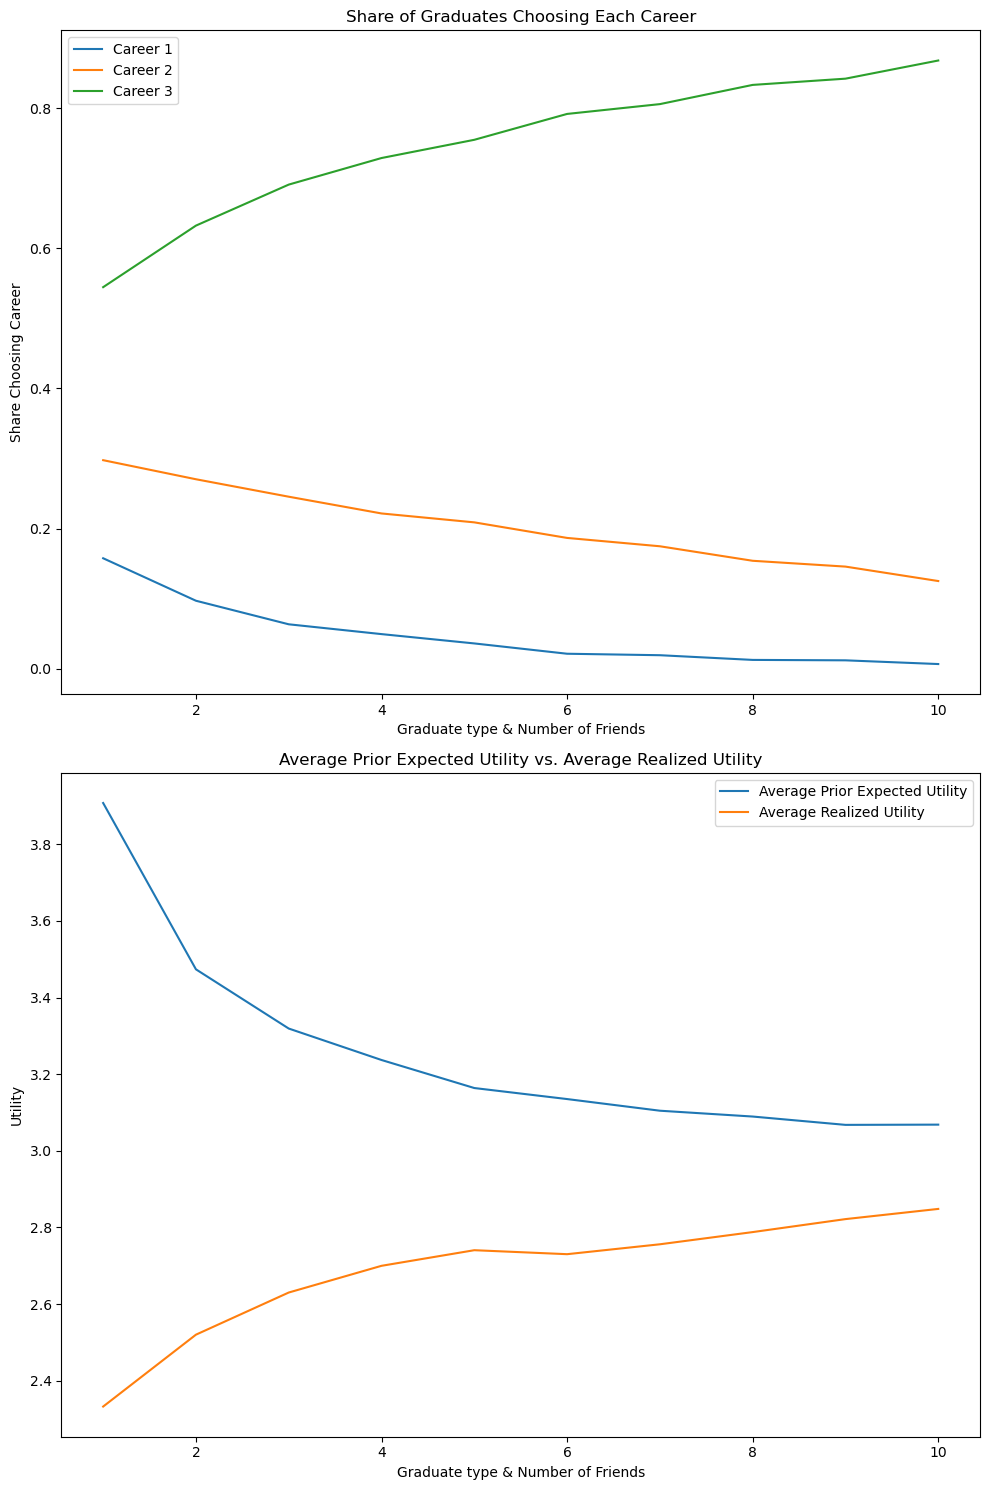

In [3]:
# This method does all the calculations and draws for question two and produced the required graphs.
# We also store key results for later use.
choices, average_prior_expected_utilities, average_realized_utilities, realized_utilities = career.simulate_career_choices(seed=seed)

**Share of graduates choosing each career**

The first graph shows the share of graduates choosing each career as number of friends increases. As expected most graduates choose career 3 since it has the highest intrinsic utility $(v_3 = 3 )$. In fact, the share of graduates choosing each career is ordered from most to least by the intrinsic utility of the career, which one would expect. 

When the number of friends in each career increases, the graduates can make better more informed desicions, as the noise will matter gradually less in their calculations. This means that more graduates will choose the *correct* career as friends-- thus information-- increases. 

**Average expected utility vs Average realized utility**

Similarly, the noise matters more when $F_i$ is small, where there is higher potential for overestimating their utility, this is why more people choose the lesser valuable careers at the starting point of the graph. This in turn means that their realized utility will be lower. As number of friends increase, their expected utility and realized utility will converge towards eachother, as seen in the graph.
__________________________________________________________________________________________

After a year of working in their career, the graduates learn $u^k_{ij}$ for their chosen job $j_i^{k*}$ perfectly. <br>
The can switch to one of the two remaining careers, for which they have the same prior as before, but it will now include a switching cost of $c$ which is known.
Their new priors can be written as: 
$$
\tilde{u}^{k,2}_{ij}\left( F_{i}\right) = \begin{cases}
            \tilde{u}^k_{ij}\left( F_{i}\right)-c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

We will set $c=1$.

Their realized utility will be: <br>
$$
u^{k,2}_{ij}= \begin{cases}
            u_{ij}^k -c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

**Question 3:** Following the same approach as in question 2, find the new optimal career choice for each $i$, $k$. Then for each $i$, calculate the average subjective expected utility from their new optimal career choice, and the ex post realized utility of that career. Also, for each $i$, calculate the share of graduates that chooses to switch careers, conditional on which career they chose in the first year. <br>
__________________________________________________________________________________________
**Answer**

This question, though different from 2.3 used much of the same method in its loop. The documentation is found in CareerChoice.py, which should be sufficient for understanding how it works. 

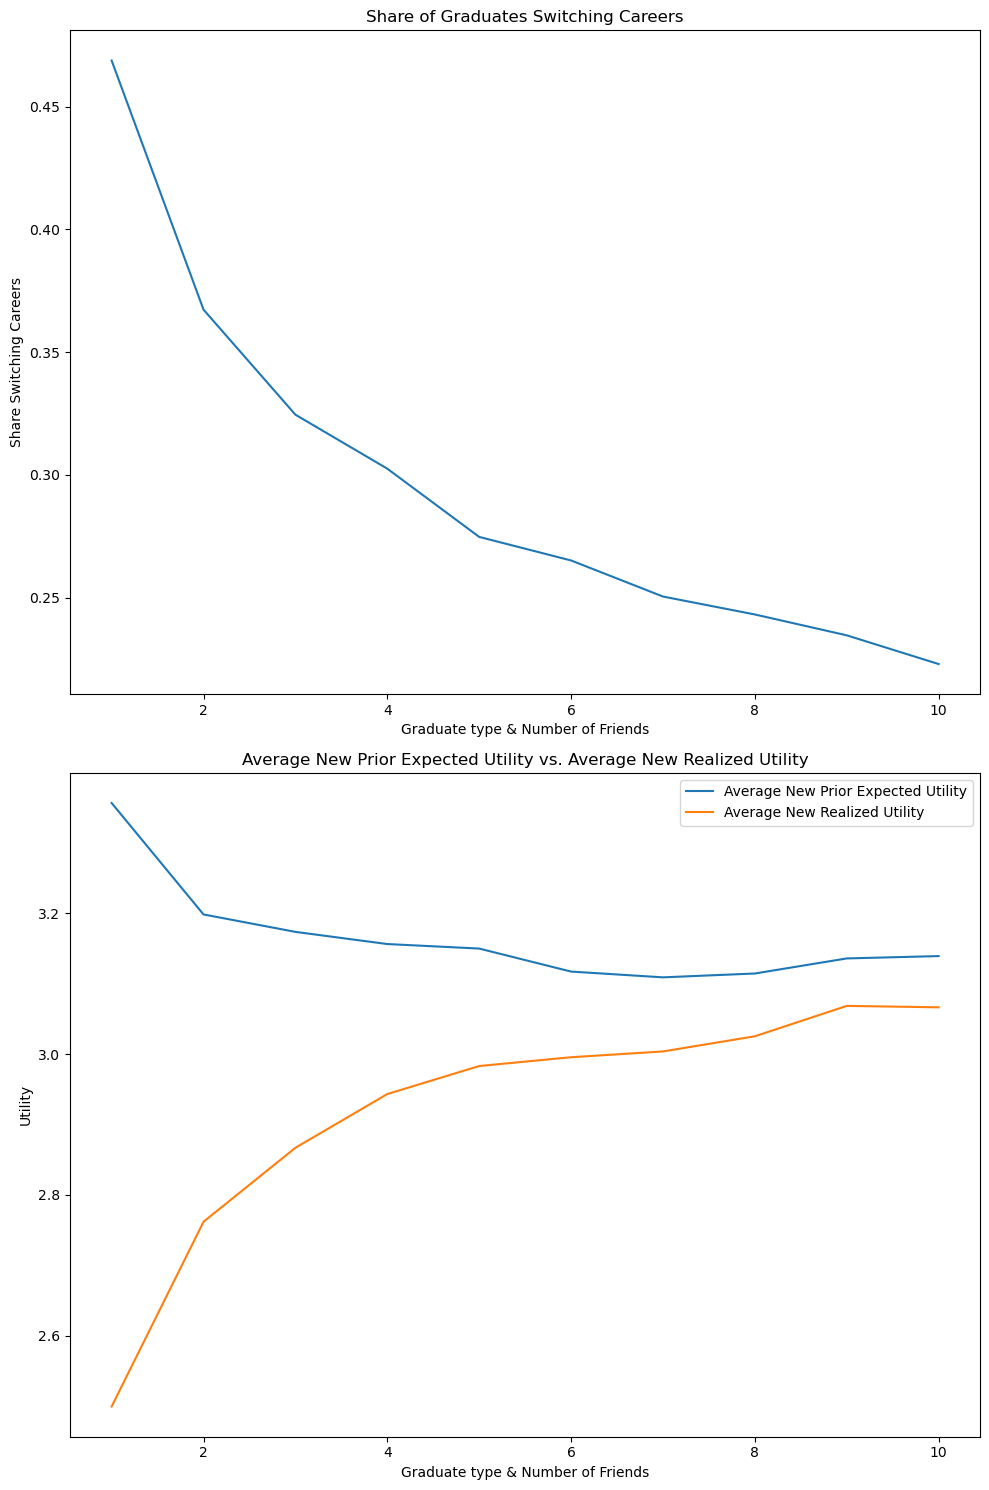

In [5]:
# we run the method that solves the question, we also unpack the results, though they arent used
# to not clutter the output. 
new_choices, average_new_prior_expected_utilities, average_new_realized_utilities, switch_decisions = career.simulate_switching_career(choices=choices, realized_utilities=realized_utilities, seed=seed)

As one would expect, there is a clear correlation between the share switching, and the shares not choosing career 3 in question 2.2. It is hard to comment specifically since there still is inherent randomness due to noise, and information not being clear such that as what career people chose from. We could analyze this further, but since comments in the first place isn't asked for in any of question 2 subquestions, we will simply comment on the results we have, which answers the questions. 

We can see that the bigger the negative gap between the average new expected utility and average new realized, the more switches are made which makes sense.
__________________________________________________________________________________________